In [218]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use('default')
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [246]:
train = pd.read_csv('data/train.csv')
test = pd.read_csv('data/test.csv')
print(f"Train shape: {train.shape}")
print(f"Test shape: {test.shape}")
print(f"Train columns: {train.columns.tolist()}\n")
train.head()

Train shape: (891, 12)
Test shape: (418, 11)
Train columns: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']



,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [220]:
train.describe().T

,count,mean,std,min,25%,50%,75%,max
PassengerId,891.0,446.000000,257.353842,1.00,223.5000,446.0000,668.5,891.0000
Survived,891.0,0.383838,0.486592,0.00,0.0000,0.0000,1.0,1.0000
Pclass,891.0,2.308642,0.836071,1.00,2.0000,3.0000,3.0,3.0000
Age,714.0,29.699118,14.526497,0.42,20.1250,28.0000,38.0,80.0000
SibSp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000
Parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000
Fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292


In [221]:
train.corr(numeric_only=True)['Survived'].sort_values()

Pclass        -0.338481
Age           -0.077221
SibSp         -0.035322
PassengerId   -0.005007
Parch          0.081629
Fare           0.257307
Survived       1.000000
Name: Survived, dtype: float64

In [222]:
train['Survived'].value_counts()


Survived
0    549
1    342
Name: count, dtype: int64

<Axes: xlabel='Survived', ylabel='count'>

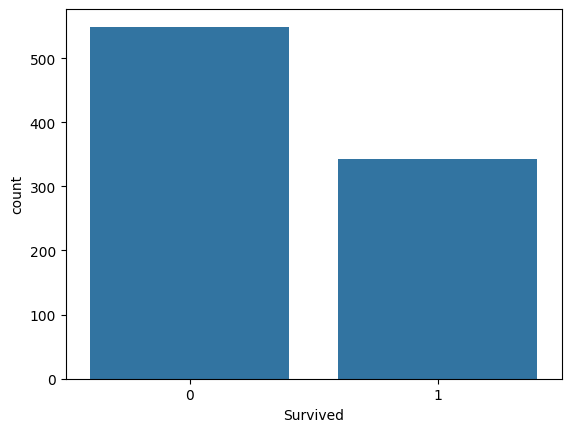

In [223]:
sns.countplot(data=train, x='Survived')

In [224]:
#missing values
info = pd.DataFrame({
    'dtype'   : train.dtypes,
    'nulls'   : train.isnull().sum(),
    'null_%'  : (train.isnull().sum() / len(train) * 100).round(1),
    'unique'  : train.nunique(),
})
print(info)

               dtype  nulls  null_%  unique
PassengerId    int64      0     0.0     891
Survived       int64      0     0.0       2
Pclass         int64      0     0.0       3
Name             str      0     0.0     891
Sex              str      0     0.0       2
Age          float64    177    19.9      88
SibSp          int64      0     0.0       7
Parch          int64      0     0.0       7
Ticket           str      0     0.0     681
Fare         float64      0     0.0     248
Cabin            str    687    77.1     147
Embarked         str      2     0.2       3


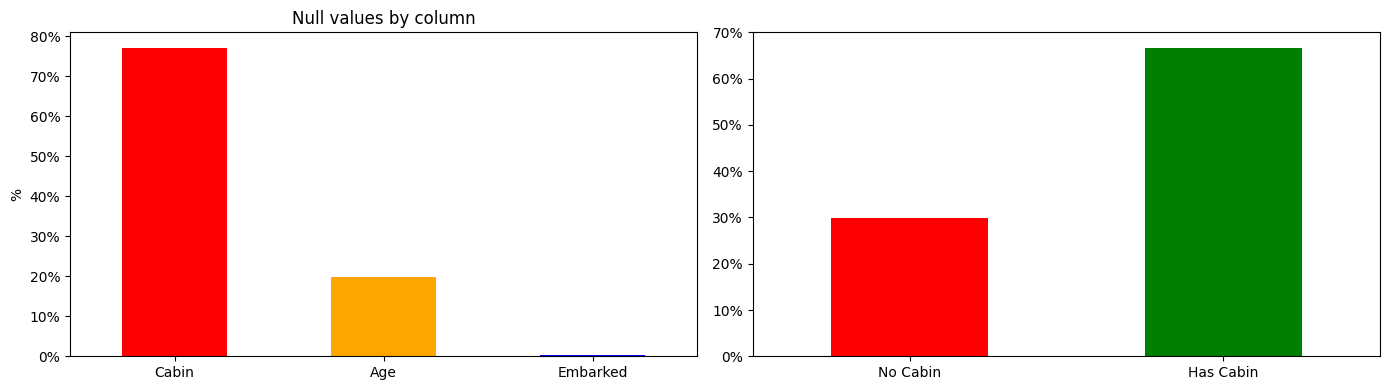

In [225]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Процент пропусков по колонкам
null_pct = train.isnull().mean() * 100
null_pct = null_pct[null_pct > 0].sort_values(ascending=False)
null_pct.plot(kind='bar', ax=axes[0], color=['red','orange','blue'])
axes[0].set_title('Null values by column')
axes[0].set_ylabel('%')
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[0].tick_params(axis='x', rotation=0)


# survived: has Cabin vs no Cabin
"""mean - процентное соотношение выживших с кабинками (кол-во выживших с кабинками / всего кол-во пассажиров с кабинками)
и без кабинок (кол-во выживших без кабинками / всего кол-во пассажиров без кабинками)
"""
train['has_cabin'] = train['Cabin'].notna().astype(int)
surv = train.groupby('has_cabin')['Survived'].mean() * 100
surv.index = ['No Cabin', 'Has Cabin']
surv.plot(kind='bar', ax=axes[1], color=['red','green'])
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

<Axes: xlabel='Survived', ylabel='Pclass'>

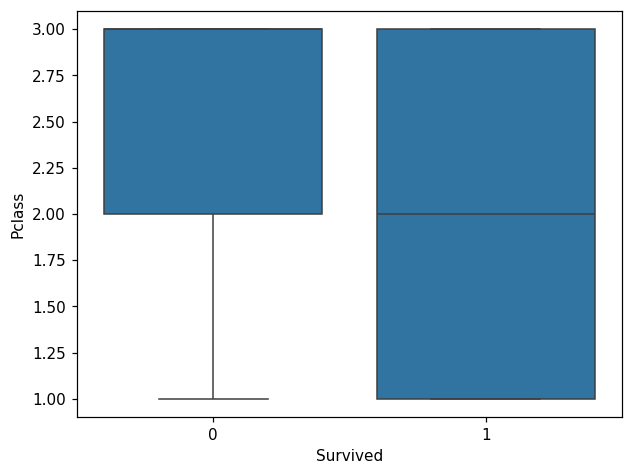

In [226]:
plt.figure(dpi=110)
sns.boxplot(x='Survived', y='Pclass', data=train)

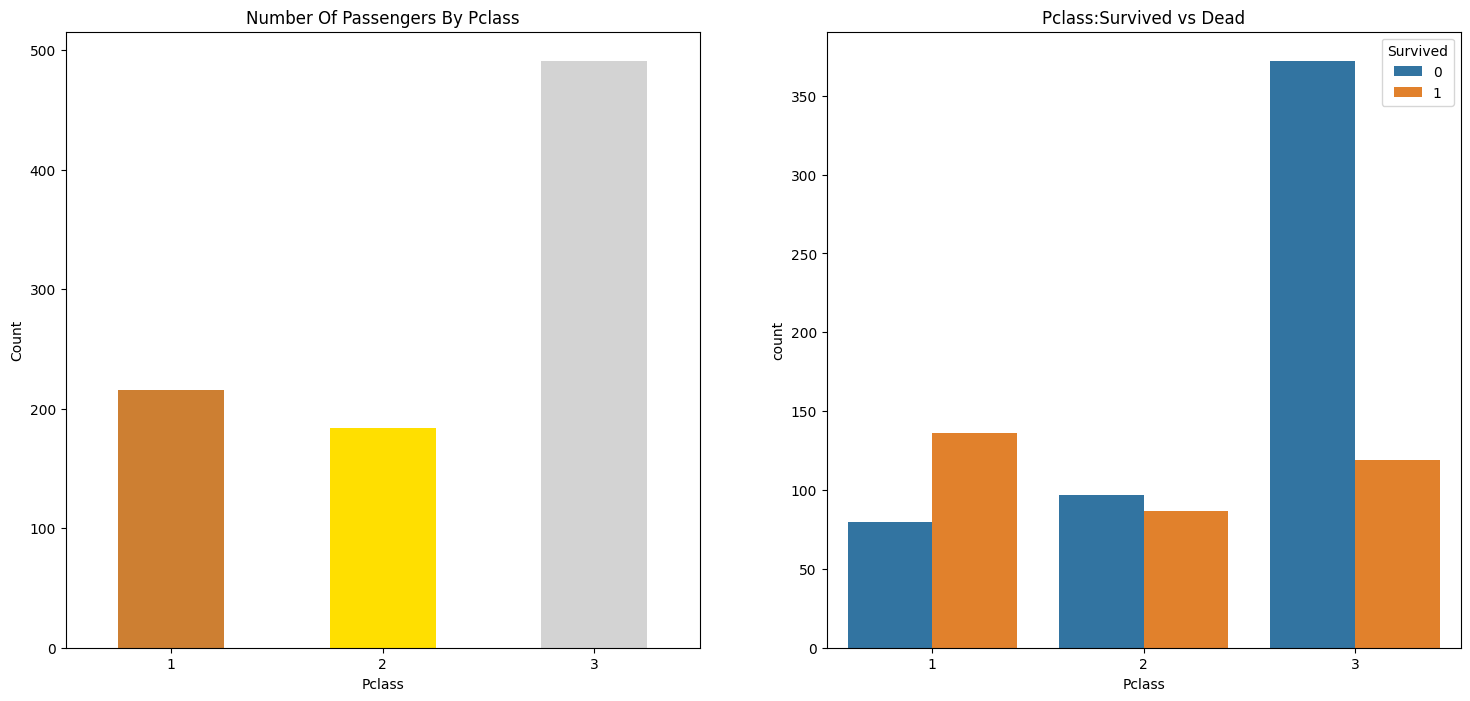

In [227]:
f,ax=plt.subplots(1,2,figsize=(18,8))
train['Pclass'].value_counts().sort_index(ascending=True).plot.bar(color=['#CD7F32','#FFDF00','#D3D3D3'],ax=ax[0], )
ax[0].set_title('Number Of Passengers By Pclass')
ax[0].set_ylabel('Count')
ax[0].tick_params(axis='x', rotation=0)

sns.countplot(x='Pclass',hue='Survived',data=train,ax=ax[1])
ax[1].set_title('Pclass:Survived vs Dead')
ax[1].tick_params(axis='x', rotation=0)
plt.show()

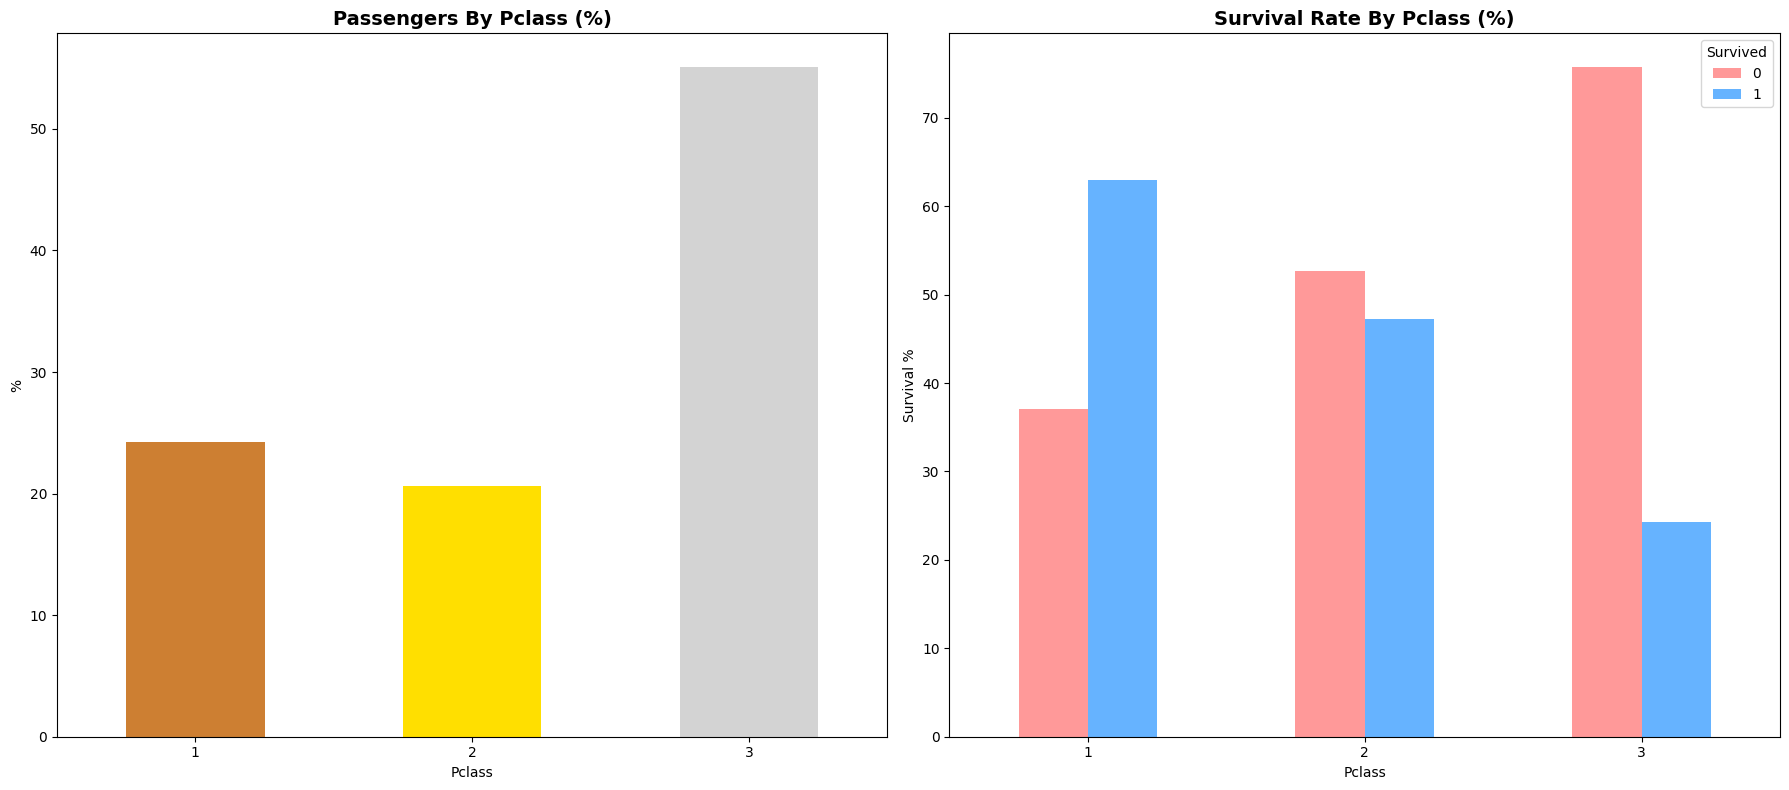

In [228]:
f, ax = plt.subplots(1, 2, figsize=(18, 8))

pclass_pct = (train['Pclass'].value_counts(normalize=True)
              .sort_index(ascending=True) * 100)
pclass_pct.plot.bar(color=['#CD7F32','#FFDF00','#D3D3D3'], ax=ax[0]) 
ax[0].set_title('Passengers By Pclass (%)', fontsize=14, fontweight='bold')
ax[0].set_ylabel('%')
ax[0].tick_params(axis='x', rotation=0)

pclass_surv_pct = pd.crosstab(train['Pclass'], train['Survived'], normalize='index') * 100
pclass_surv_pct.plot.bar(ax=ax[1], color=['#ff9999','#66b3ff'])
ax[1].set_title('Survival Rate By Pclass (%)', fontsize=14, fontweight='bold')
ax[1].set_ylabel('Survival %')
ax[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()


<Axes: xlabel='Survived', ylabel='Age'>

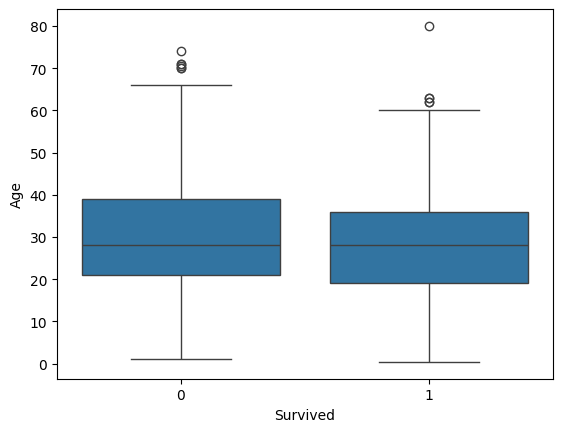

In [229]:
plt.figure(dpi=100)
sns.boxplot(x='Survived', y='Age', data=train)

Text(0.5, 1.0, 'Fare (log scale)')

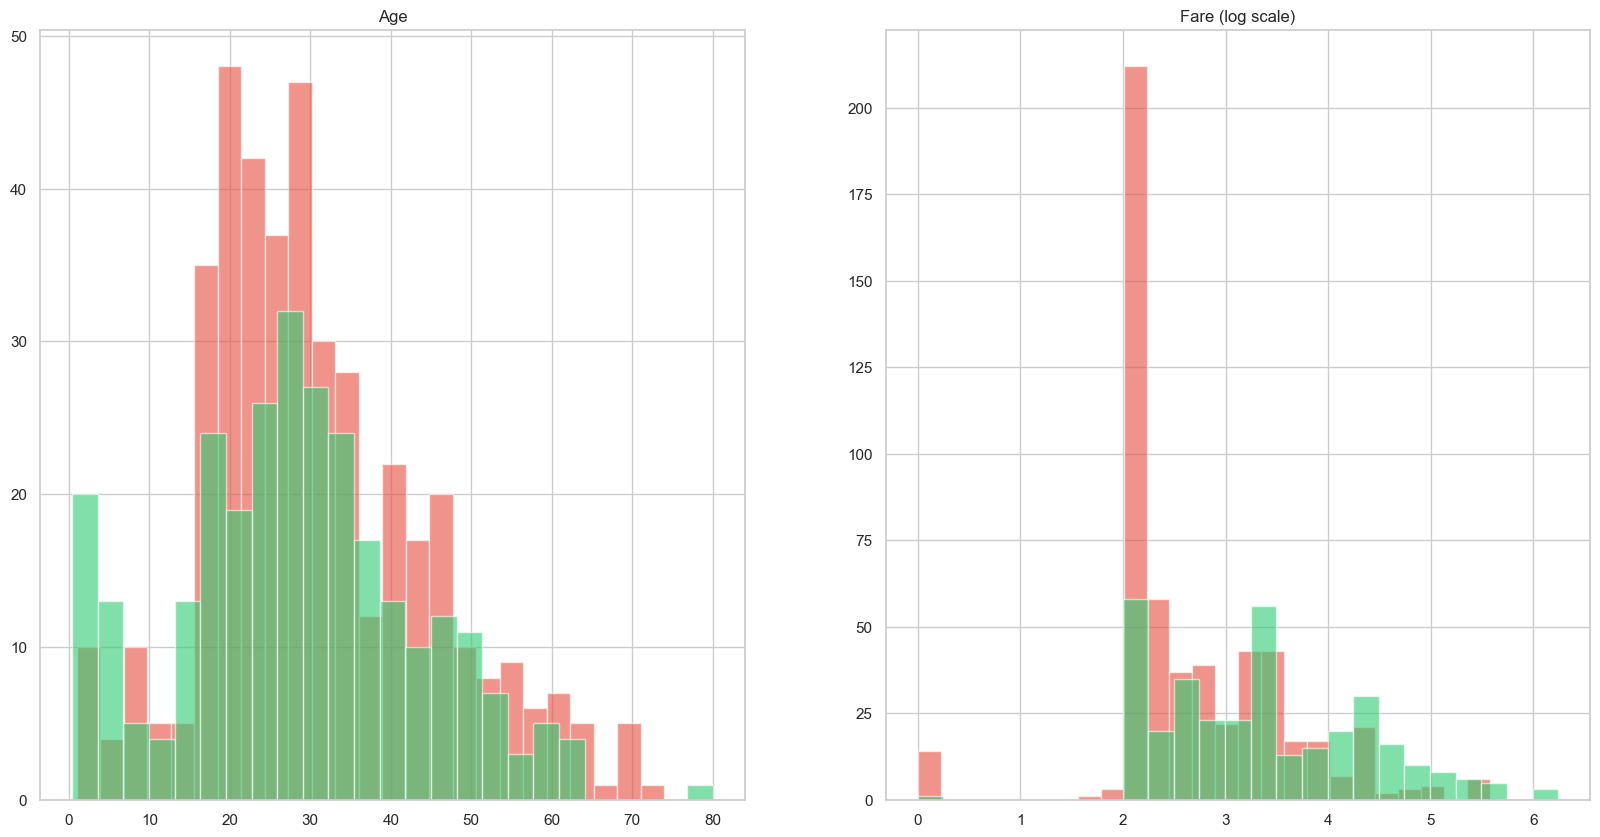

In [230]:
sns.set_theme(style='whitegrid', palette='muted')
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

for survived, label, color in [(0,'0','#e74c3c'), (1,'1','#2ecc71')]:
    subset = train[train['Survived'] == survived]['Age'].dropna()
    axes[0].hist(subset, bins=25, alpha=0.6, label=label, color=color)
axes[0].set_title('Age')

for survived, label, color in [(0,'0','#e74c3c'), (1,'1','#2ecc71')]:
    subset = train[train['Survived'] == survived]['Fare']
    subset_log = np.log1p(subset)
    axes[1].hist(subset_log, bins=25, alpha=0.6, label=label, color=color)
axes[1].set_title('Fare (log scale)')

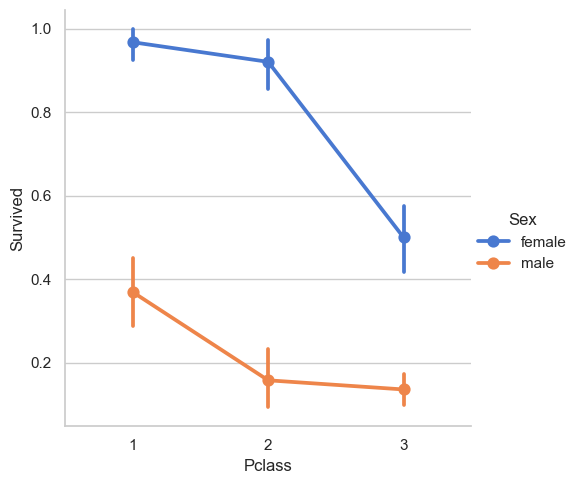

In [231]:
sns.catplot(x='Pclass', y='Survived', hue='Sex', data=train, kind='point')
plt.show()

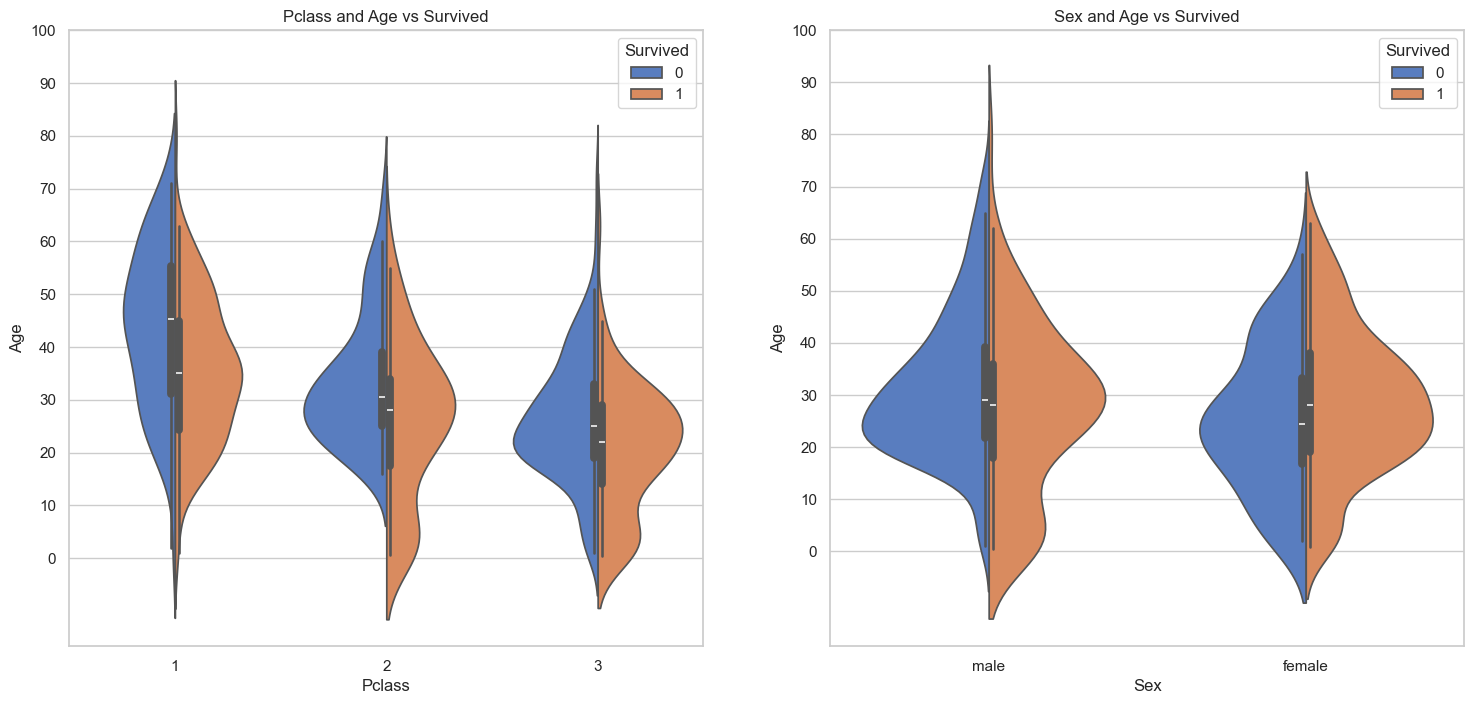

In [232]:
f,ax=plt.subplots(1,2,figsize=(18,8))
sns.violinplot(x="Pclass",y="Age", hue="Survived", data=train,split=True,ax=ax[0])
ax[0].set_title('Pclass and Age vs Survived')
ax[0].set_yticks(range(0,110,10))

sns.violinplot(x="Sex",y="Age", hue="Survived", data=train,split=True,ax=ax[1])
ax[1].set_title('Sex and Age vs Survived')
ax[1].set_yticks(range(0,110,10))
plt.show()

<Axes: xlabel='Survived', ylabel='SibSp'>

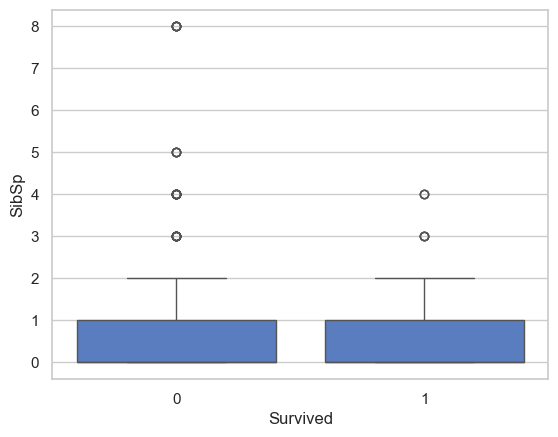

In [233]:
plt.figure(dpi=100)
sns.boxplot(x='Survived', y='SibSp', data=train)

In [234]:
pd.crosstab([train.SibSp],train.Survived)

Survived,0,1
SibSp,,
0,398,210
1,97,112
2,15,13
3,12,4
4,15,3
5,5,0
8,7,0


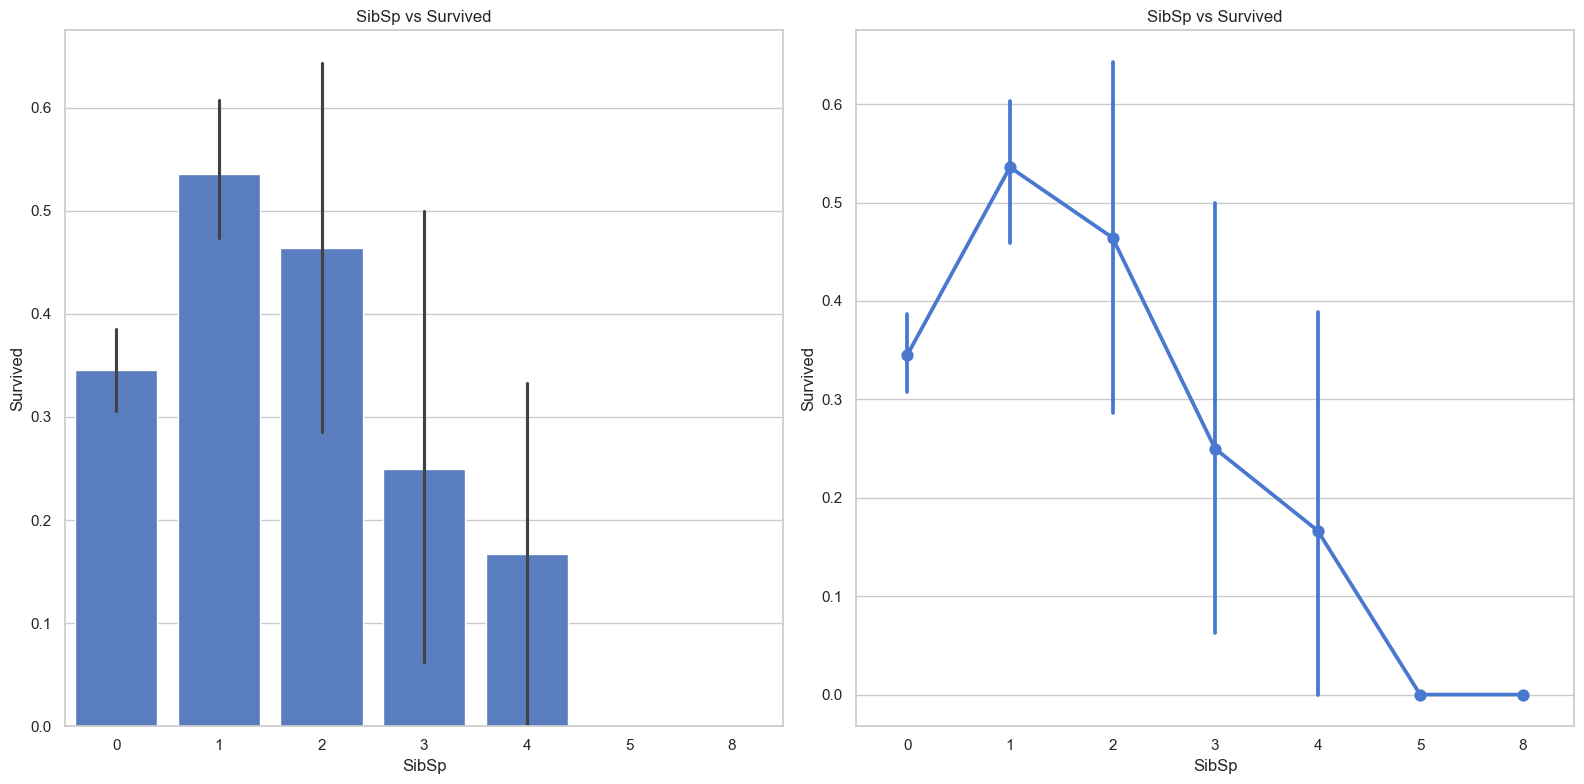

In [235]:
f, ax = plt.subplots(1, 2, figsize=(16, 8))

sns.barplot(x='SibSp', y='Survived', data=train, ax=ax[0])
ax[0].set_title('SibSp vs Survived')

sns.pointplot(x='SibSp', y='Survived', data=train, ax=ax[1])
ax[1].set_title('SibSp vs Survived')

plt.tight_layout()
plt.show()


In [236]:
pd.crosstab(train.SibSp,train.Pclass)

Pclass,1,2,3
SibSp,,,
0,137,120,351
1,71,55,83
2,5,8,15
3,3,1,12
4,0,0,18
5,0,0,5
8,0,0,7


<Axes: xlabel='Survived', ylabel='Parch'>

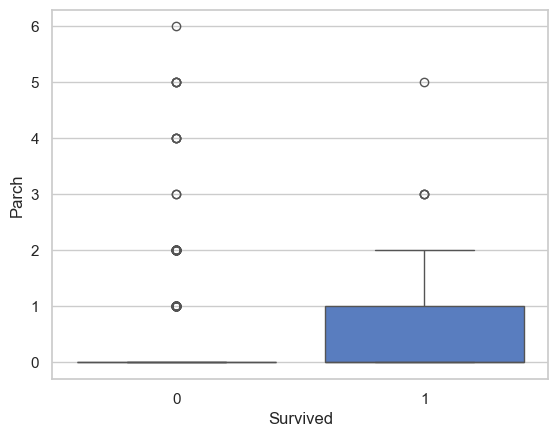

In [237]:
plt.figure(dpi=100)
sns.boxplot(x='Survived', y='Parch', data=train)

In [238]:
pd.crosstab(train.Parch,train.Pclass)

Pclass,1,2,3
Parch,,,
0,163,134,381
1,31,32,55
2,21,16,43
3,0,2,3
4,1,0,3
5,0,0,5
6,0,0,1


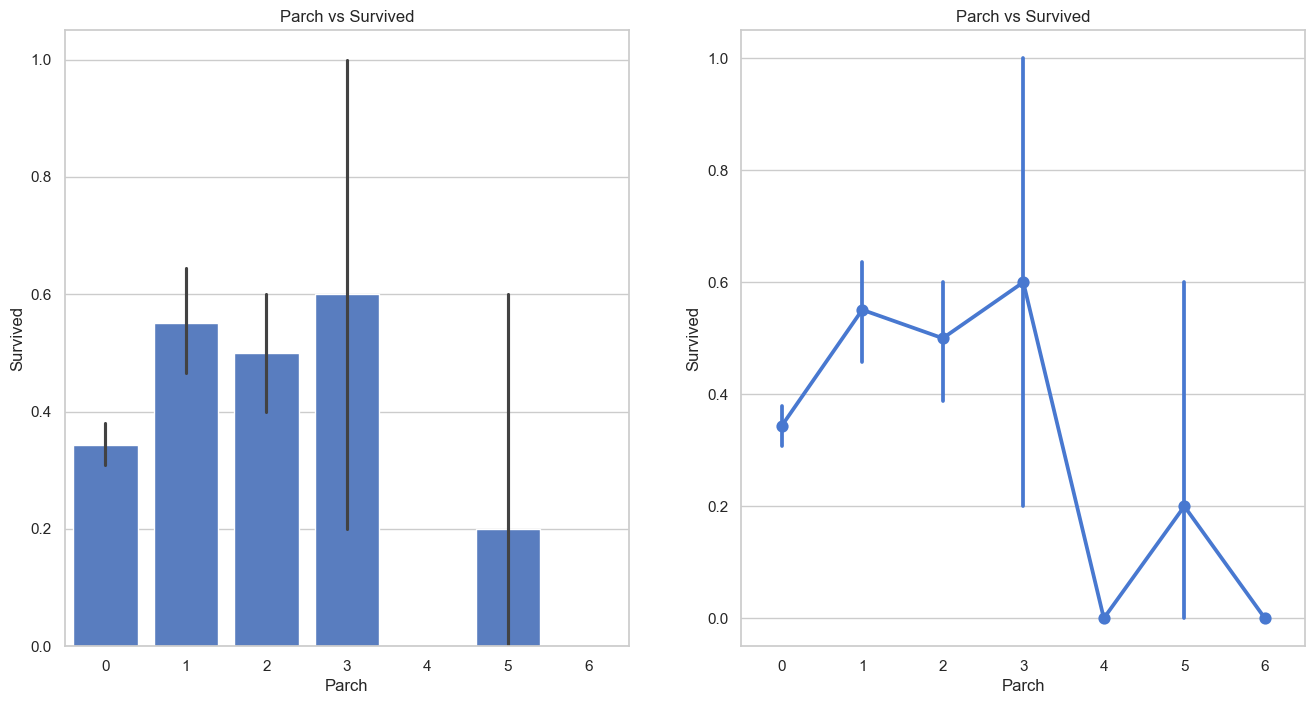

In [239]:
f,ax=plt.subplots(1,2,figsize=(16,8))
sns.barplot(x='Parch',y='Survived',data=train,ax=ax[0])
ax[0].set_title('Parch vs Survived')

sns.pointplot(x='Parch',y='Survived',data=train,ax=ax[1])
ax[1].set_title('Parch vs Survived')
plt.close(2)
plt.show()

<Axes: xlabel='Survived', ylabel='Fare'>

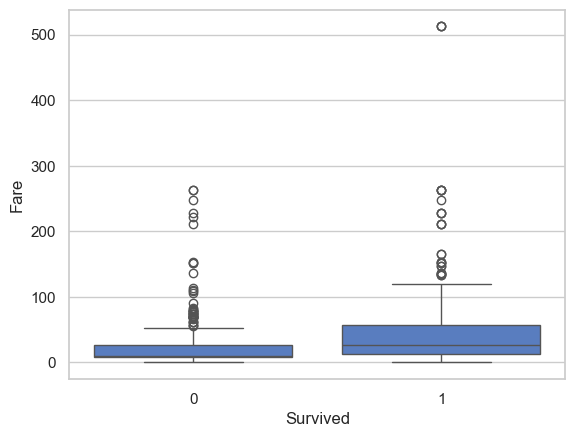

In [240]:
plt.figure(dpi=100)
sns.boxplot(x='Survived', y='Fare', data=train)

In [241]:
print('Highest Fare was:',train['Fare'].max())
print('Lowest Fare was:',train['Fare'].min())
print('Average Fare was:',train['Fare'].mean())

Highest Fare was: 512.3292
Lowest Fare was: 0.0
Average Fare was: 32.204207968574636


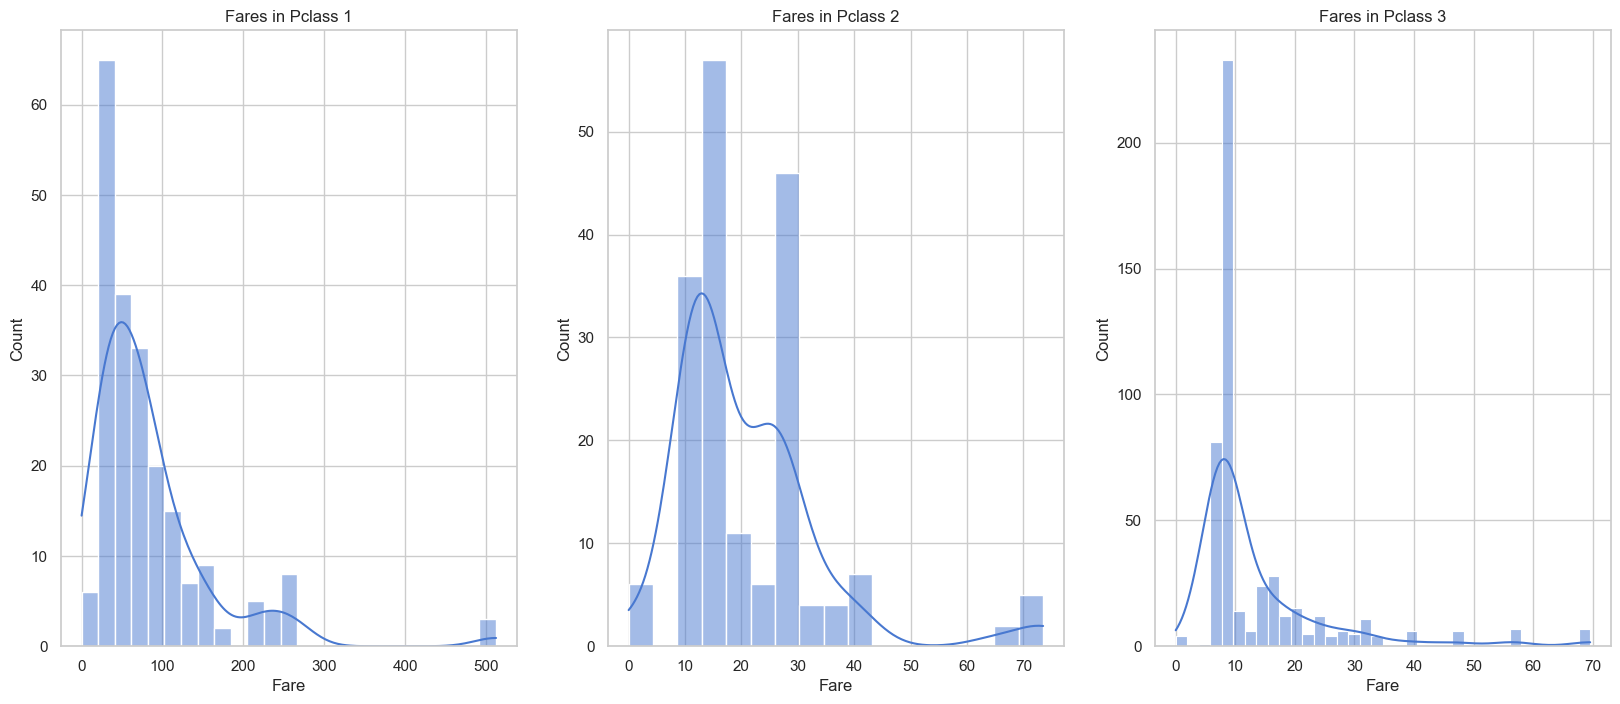

In [242]:
f, ax = plt.subplots(1, 3, figsize=(20, 8))

sns.histplot(data=train[train['Pclass']==1]['Fare'], ax=ax[0], kde=True)
ax[0].set_title('Fares in Pclass 1')

sns.histplot(data=train[train['Pclass']==2]['Fare'], ax=ax[1], kde=True)
ax[1].set_title('Fares in Pclass 2')

sns.histplot(data=train[train['Pclass']==3]['Fare'], ax=ax[2], kde=True)
ax[2].set_title('Fares in Pclass 3')

plt.show()


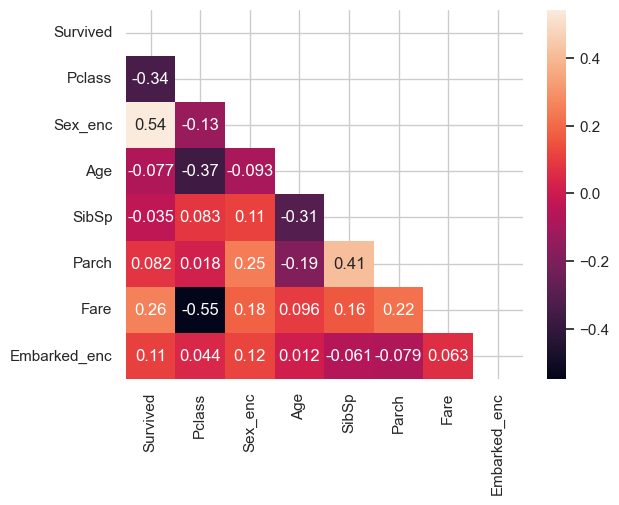

In [243]:
train_corr=train.copy()
train_corr['Sex_enc']=(train_corr['Sex']=='female').astype(int)
train_corr['Embarked_enc']=train_corr['Embarked'].map({'S':0,'C':1,'Q':2})

corr_cols =["Survived","Pclass","Sex_enc","Age","SibSp","Parch","Fare","Embarked_enc"]
corr = train_corr[corr_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr,annot=True,mask=mask)
plt.show()

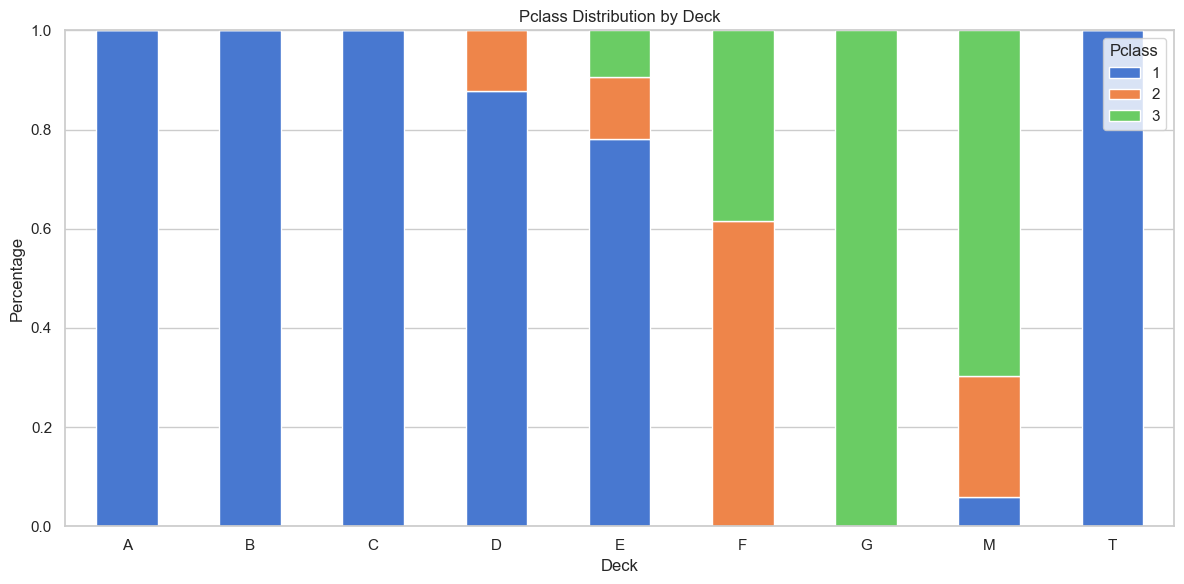

In [249]:
train['Deck'] = train['Cabin'].apply(lambda s: s[0] if pd.notnull(s) else 'M')

train_decks = train.groupby(['Deck', 'Pclass']).count().drop(columns=['Survived', 'Sex', 'Age', 'SibSp', 'Parch', 
    'Fare', 'Embarked', 'Cabin', 'PassengerId', 'Ticket']).rename(columns={'Name': 'Count'}).transpose()

train_decks = train.groupby(['Deck', 'Pclass']).size().unstack(fill_value=0)
train_decks.div(train_decks.sum(axis=1), axis=0).plot(kind='bar', stacked=True, figsize=(12,6))
plt.title('Pclass Distribution by Deck')
plt.ylabel('Percentage')
plt.xticks(rotation=0)
plt.legend(title='Pclass')
plt.tight_layout()
plt.show()


train_decks:
 Pclass   1    2    3
Deck                
A       15    0    0
B       47    0    0
C       59    0    0
D       29    4    0
E       25    4    3
F        0    8    5
G        0    0    4
M       40  168  479
T        1    0    0
✅ Классы: [1, 2, 3]


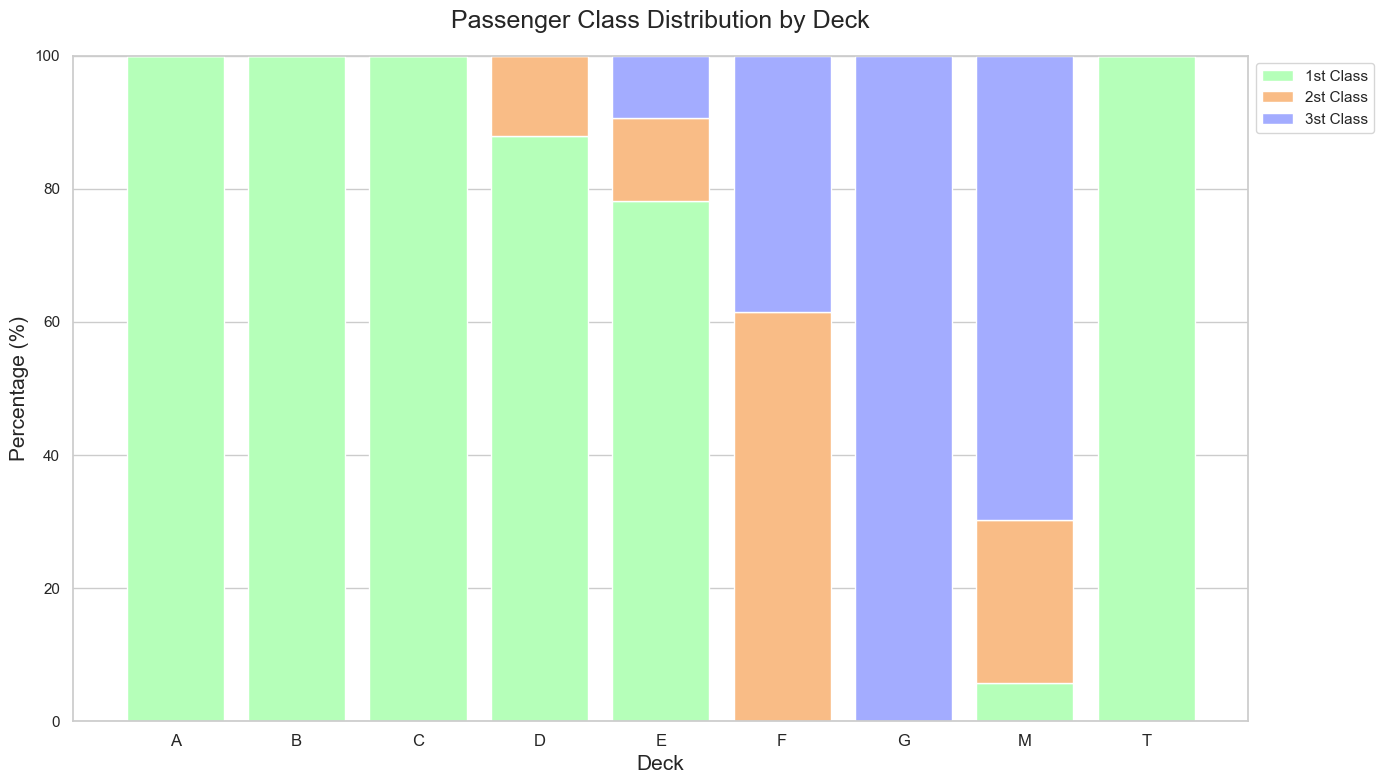

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# 1. Deck колонка
train['Deck'] = train['Cabin'].apply(lambda s: s[0] if pd.notnull(s) else 'M')
test['Deck'] = test['Cabin'].apply(lambda s: s[0] if pd.notnull(s) else 'M')

# 2. Группировка
train_decks = train.groupby(['Deck', 'Pclass']).size().unstack(fill_value=0)
test_decks = test.groupby(['Deck', 'Pclass']).size().unstack(fill_value=0)
print("train_decks:\n", train_decks)


def plot_deck_distribution(df):
    """Строит график БЕЗ ошибок индексации"""
    # Проценты
    df_pct = df.div(df.sum(axis=1), axis=0) * 100
    
    # Только существующие классы
    available_classes = [col for col in [1,2,3] if col in df_pct.columns]
    print(" Классы:", available_classes)
    
    fig, ax = plt.subplots(figsize=(14, 8))
    bottom = np.zeros(len(df_pct))
    
    colors = ['#b5ffb9', '#f9bc86', '#a3acff']
    deck_names = df_pct.index
    
    for i, pclass in enumerate(available_classes):
        values = df_pct[pclass].values
        ax.bar(deck_names, values, bottom=bottom, 
               label=f'{pclass}st Class', color=colors[i], 
               edgecolor='white', width=0.8)
        bottom += values
    
    ax.set_xlabel('Deck', size=15)
    ax.set_ylabel('Percentage (%)', size=15)
    ax.set_title('Passenger Class Distribution by Deck', size=18, pad=20)
    ax.legend(loc='upper left', bbox_to_anchor=(1, 1))
    ax.tick_params(axis='x', labelsize=12, rotation=0)
    plt.tight_layout()
    plt.show()

# 4. ЗАПУСК
plot_deck_distribution(train_decks)


In [2]:
summary = """
=== ИТОГИ EDA ===

ПРОПУСКИ:
  Age    (19.9%) → заполнить медианой по группе Pclass+Sex+Title (пропуски НЕ случайны)
  Cabin  (77.1%) → не восстанавливать; извлечь Deck (буква) + has_cabin (бинарный флаг)
  Embarked (0.2%) → заполнить модой ('S')
  Fare=0  (15 пасс.) → заменить медианой по Pclass

СИЛЬНЫЕ ПРИЗНАКИ (по убыванию важности):
  1. Sex       — самый сильный (женщины 74% vs мужчины 19%)
  2. Pclass    — второй по силе (1кл: 63%, 3кл: 24%)
  3. Title     — кодирует Sex+Age+статус одновременно
  4. Fare_log  — высокий тариф = выше класс = выше шансы

КОДИРОВАНИЕ КАТЕГОРИЙ:
  Sex, Embarked → LabelEncoder или OHE
  Title, Deck, FamilyGroup → OHE (для линейных) или target encoding (для бустингов)

ДИСБАЛАНС КЛАССОВ:
  38% / 62% — умеренный → обязательно Stratified K-Fold

НОРМАЛИЗАЦИЯ:
  Нужна для: KNN, Logistic Regression, SVM, DNN
  Не нужна для: Decision Tree, Random Forest, Gradient Boosting
"""
print(summary)


=== ИТОГИ EDA ===

ПРОПУСКИ:
  Age    (19.9%) → заполнить медианой по группе Pclass+Sex+Title (пропуски НЕ случайны)
  Cabin  (77.1%) → не восстанавливать; извлечь Deck (буква) + has_cabin (бинарный флаг)
  Embarked (0.2%) → заполнить модой ('S')
  Fare=0  (15 пасс.) → заменить медианой по Pclass

СИЛЬНЫЕ ПРИЗНАКИ (по убыванию важности):
  1. Sex       — самый сильный (женщины 74% vs мужчины 19%)
  2. Pclass    — второй по силе (1кл: 63%, 3кл: 24%)
  3. Title     — кодирует Sex+Age+статус одновременно
  4. Fare_log  — высокий тариф = выше класс = выше шансы

КОДИРОВАНИЕ КАТЕГОРИЙ:
  Sex, Embarked → LabelEncoder или OHE
  Title, Deck, FamilyGroup → OHE (для линейных) или target encoding (для бустингов)

ДИСБАЛАНС КЛАССОВ:
  38% / 62% — умеренный → обязательно Stratified K-Fold

НОРМАЛИЗАЦИЯ:
  Нужна для: KNN, Logistic Regression, SVM, DNN
  Не нужна для: Decision Tree, Random Forest, Gradient Boosting

